<a href="https://colab.research.google.com/github/ranjetmahato416/-Lung-CT-Image-Classification-Using-Public-Medical-Imaging-Data-/blob/main/Desktop/Colab_Notebook/Notebook/Notebook_10_EfficientNetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Overview

In [1]:
# ============================================================
# Notebook 10
# EfficientNetB0 Training
# ============================================================

# Purpose:
# Train EfficientNetB0 for lung nodule
# benign vs malignant classification.
#
# Dataset:
# - train.csv
# - validation.csv
# - test.csv
#
# Image size:
# 128 x 128
#
# Transfer Learning:
# Stage 1:
# Frozen backbone
#
# Stage 2:
# Fine tuning
#
# ============================================================

##2. Imports

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


##3. Mount Drive

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 4. Project Paths and Output Directories

In [4]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Dissertation"
)

PROCESSED_PATH = (
    DRIVE_ROOT /
    "Dataset" /
    "Processed"
)

MODEL_PATH = (
    DRIVE_ROOT /
    "Models"
)

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_CSV = PROCESSED_PATH / "train.csv"
VALIDATION_CSV = PROCESSED_PATH / "validation.csv"
TEST_CSV = PROCESSED_PATH / "test.csv"

##5. Load Dataset

In [5]:
train_df = pd.read_csv(TRAIN_CSV)

validation_df = pd.read_csv(VALIDATION_CSV)

test_df = pd.read_csv(TEST_CSV)

print(train_df.shape)
print(validation_df.shape)
print(test_df.shape)

(1149, 5)
(237, 5)
(256, 5)


##6. Global Configuration

In [6]:
IMAGE_SIZE = (128, 128)

BATCH_SIZE = 16

AUTOTUNE = tf.data.AUTOTUNE

SEED = 42

tf.random.set_seed(SEED)

np.random.seed(SEED)

##7. Compute Class Weights

In [7]:
classes = np.unique(train_df["CancerLabel"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["CancerLabel"]
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5699404761904762), np.int64(1): np.float64(4.074468085106383)}


##8. Image Loading Function

In [8]:
def load_image(path, label):
    """
    Load an RGB PNG for EfficientNet.

    Important:
    EfficientNetB0 includes internal rescaling and expects
    float32 pixel values in the range 0–255.
    """

    image = tf.io.read_file(path)

    image = tf.image.decode_png(
        image,
        channels=3
    )

    # Keep the original 0–255 scale.
    image = tf.cast(
        image,
        tf.float32
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="area"
    )

    image = tf.clip_by_value(
        image,
        0.0,
        255.0
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label

####8.1. Data Augmentation

In [9]:
# ============================================================
# Data Augmentation
# ============================================================

augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.05
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomTranslation(
        0.05,
        0.05
    )

])

####8.2 Apply Augmentations

In [10]:
# ============================================================
# Apply Augmentation
# ============================================================

def augment(image, label):

    image = augmentation(
        image,
        training=True
    )

    return image, label

####8.3 Dataset Builder



In [11]:
# ============================================================
# Build TensorFlow Dataset
# ============================================================

def build_dataset(df, training=False):

    paths = df["ImagePath"].values

    labels = df["CancerLabel"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if training:

        ds = ds.shuffle(
            buffer_size=len(df),
            seed=42
        )

        ds = ds.map(
            augment,
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(
        AUTOTUNE
    )

    return ds

In [12]:
train_ds = build_dataset(train_df, training=True)

validation_ds = build_dataset(validation_df)

test_ds = build_dataset(test_df)

##9. Build EfficientNetB0 Backbone

In [13]:
# ============================================================
# Section 9 - Build EfficientNetB0
# ============================================================

base_model = tf.keras.applications.EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(128,128,3)
)

base_model.trainable = False

print("Trainable layers:", len(base_model.trainable_variables))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable layers: 0


##10. Build Classification Head

In [14]:
inputs = tf.keras.Input(shape=(128,128,3))

x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.30)(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

##11. Model Summary

In [15]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

##12. Compile Frozen-Backbone Model

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

##13. Define Baseline Output Paths

In [17]:
# ============================================================
# Section 13 - Output Directories
# ============================================================

CHECKPOINT_DIR = MODEL_PATH / "EfficientNetB0"

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL = CHECKPOINT_DIR / "best_model.keras"

FINAL_MODEL = CHECKPOINT_DIR / "final_model.keras"

HISTORY_FILE = CHECKPOINT_DIR / "training_history.csv"

LOG_DIR = CHECKPOINT_DIR / "logs"

LOG_DIR.mkdir(
    exist_ok=True
)

print(CHECKPOINT_DIR)

/content/drive/MyDrive/Dissertation/Models/EfficientNetB0


##14. Define Baseline Callbacks

In [18]:
# ============================================================
# Section 11 - Callbacks
# ============================================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL),
    monitor="val_pr_auc",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=8,
    min_delta=0.002,
    restore_best_weights=True,
    verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
    ),

    tf.keras.callbacks.CSVLogger(

        HISTORY_FILE,

        append=False
    ),

    tf.keras.callbacks.TensorBoard(

        log_dir=LOG_DIR
    )

]

##15. Train Frozen-Backbone Baseline

In [19]:
# ============================================================
# Section 12 - Stage 1 Training
# ============================================================

INITIAL_EPOCHS = 25

history = model.fit(

    train_ds,

    validation_data=validation_ds,

    epochs=INITIAL_EPOCHS,

    class_weight=class_weights,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.6039 - auc: 0.6029 - loss: 0.7306 - pr_auc: 0.2127 - precision: 0.1839 - recall: 0.5191
Epoch 1: val_pr_auc improved from None to 0.43383, saving model to /content/drive/MyDrive/Dissertation/Models/EfficientNetB0/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dissertation/Models/EfficientNetB0/best_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 260s 958ms/step - accuracy: 0.6571 - auc: 0.6579 - loss: 0.6526 - pr_auc: 0.2144 - precision: 0.1907 - recall: 0.5532 - val_accuracy: 0.8439 - val_auc: 0.7713 - val_loss: 0.5377 - val_pr_auc: 0.4338 - val_precision: 0.3846 - val_recall: 0.5357 - learning_rate: 1.0000e-04
Epoch 2/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7636 - auc: 0.8024 - loss: 0.5260 - pr_auc: 0.3839 - precision: 0.2719 - recall: 0.6610
Epoch 2: val_pr_auc improved from 0.43383 to 0.47536, saving model to /content/drive/MyDrive/Dissertation/Models/EfficientNetB0/best_model.ker

##16. Save the Final Baseline Model

In [20]:
# ============================================================
# Section 13 - Save Final Model
# ============================================================

model.save(FINAL_MODEL)

print("Saved:", FINAL_MODEL)

Saved: /content/drive/MyDrive/Dissertation/Models/EfficientNetB0/final_model.keras


##17. Plot Baseline Training Curves

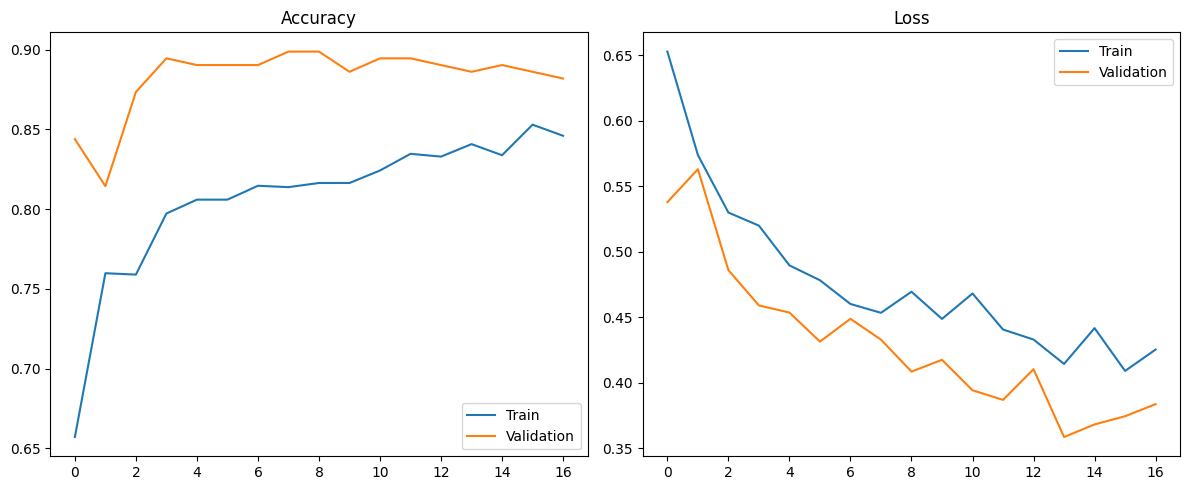

In [21]:
# ============================================================
# Section 17 - Learning Curves
# ============================================================

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history_df["accuracy"], label="Train")

plt.plot(history_df["val_accuracy"], label="Validation")

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history_df["loss"], label="Train")

plt.plot(history_df["val_loss"], label="Validation")

plt.title("Loss")

plt.legend()

plt.tight_layout()

plt.show()

## 18. Load Best Frozen-Backbone Checkpoint

In [22]:
baseline_model = tf.keras.models.load_model(
    BEST_MODEL
)

print("Loaded baseline checkpoint:")
print(BEST_MODEL)

Loaded baseline checkpoint:
/content/drive/MyDrive/Dissertation/Models/EfficientNetB0/best_model.keras


## 19. Evaluate Baseline Model on Validation Set

In [23]:
y_val = np.concatenate([
    labels.numpy().reshape(-1)
    for _, labels in validation_ds
])

y_val_prob_baseline = baseline_model.predict(
    validation_ds,
    verbose=1
).reshape(-1)

print("Labels shape:", y_val.shape)
print(
    "Predictions shape:",
    y_val_prob_baseline.shape
)

print(
    "Prediction minimum:",
    y_val_prob_baseline.min()
)

print(
    "Prediction maximum:",
    y_val_prob_baseline.max()
)

print(
    "Prediction mean:",
    y_val_prob_baseline.mean()
)

print(
    "Validation ROC-AUC:",
    roc_auc_score(
        y_val,
        y_val_prob_baseline
    )
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 632ms/step
Labels shape: (237,)
Predictions shape: (237,)
Prediction minimum: 0.08303629
Prediction maximum: 0.9775869
Prediction mean: 0.3171364
Validation ROC-AUC: 0.8327067669172933


### 19.1 Select Baseline Validation Thresholds

In [24]:
precision_baseline, recall_baseline, thresholds_baseline = (
    precision_recall_curve(
        y_val,
        y_val_prob_baseline
    )
)

f1_scores_baseline = (
    2
    * precision_baseline
    * recall_baseline
    / (
        precision_baseline
        + recall_baseline
        + 1e-8
    )
)

baseline_best_index = np.argmax(
    f1_scores_baseline[:-1]
)

baseline_f1_threshold = (
    thresholds_baseline[
        baseline_best_index
    ]
)

print(
    "Baseline F1 threshold:",
    baseline_f1_threshold
)

print(
    "Precision:",
    precision_baseline[
        baseline_best_index
    ]
)

print(
    "Recall:",
    recall_baseline[
        baseline_best_index
    ]
)

print(
    "F1:",
    f1_scores_baseline[
        baseline_best_index
    ]
)

Baseline F1 threshold: 0.43200374
Precision: 0.5333333333333333
Recall: 0.5714285714285714
F1: 0.5517241329369797


### 19.2 Baseline Validation Report at F1 Threshold

In [25]:
y_val_pred_baseline_f1 = (
    y_val_prob_baseline
    >= baseline_f1_threshold
).astype(np.int32)

baseline_val_cm = confusion_matrix(
    y_val,
    y_val_pred_baseline_f1
)

print("Confusion matrix:")
print(baseline_val_cm)

print(
    classification_report(
        y_val,
        y_val_pred_baseline_f1,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4,
        zero_division=0
    )
)

Confusion matrix:
[[195  14]
 [ 12  16]]
              precision    recall  f1-score   support

      Benign     0.9420    0.9330    0.9375       209
   Malignant     0.5333    0.5714    0.5517        28

    accuracy                         0.8903       237
   macro avg     0.7377    0.7522    0.7446       237
weighted avg     0.8937    0.8903    0.8919       237



### 19.3 Select Baseline High-Recall Threshold

In [26]:
TARGET_RECALL = 0.70

valid_indices = np.where(
    recall_baseline[:-1]
    >= TARGET_RECALL
)[0]

if len(valid_indices) > 0:

    baseline_high_recall_index = (
        valid_indices[
            np.argmax(
                precision_baseline[
                    valid_indices
                ]
            )
        ]
    )

    baseline_high_recall_threshold = (
        thresholds_baseline[
            baseline_high_recall_index
        ]
    )

    print(
        "High-recall threshold:",
        baseline_high_recall_threshold
    )

    print(
        "Precision:",
        precision_baseline[
            baseline_high_recall_index
        ]
    )

    print(
        "Recall:",
        recall_baseline[
            baseline_high_recall_index
        ]
    )

else:
    baseline_high_recall_threshold = None

    print(
        "No threshold achieved",
        TARGET_RECALL,
        "recall."
    )

High-recall threshold: 0.33618408
Precision: 0.2702702702702703
Recall: 0.7142857142857143


## 20. Experiment 2 — Fine-Tune the Final 30 EfficientNetB0 Layers

In Experiment 1, the EfficientNetB0 convolutional backbone was kept frozen and only the custom classification head was trained. That stage established a transfer-learning baseline using ImageNet-pretrained features.

In Experiment 2, the best checkpoint from the frozen-backbone baseline is loaded and used as the starting point for fine-tuning. The final 30 layers of the EfficientNetB0 backbone are made trainable so that higher-level pretrained features can adapt to lung nodule texture, margins, shape and surrounding tissue patterns.

To reduce instability and overfitting:

- all earlier EfficientNetB0 layers remain frozen;
- all BatchNormalization layers remain frozen;
- the model is recompiled with a lower learning rate of `1e-5`;
- the same binary cross-entropy loss and class weights are retained;
- model selection is based on validation PR-AUC.

This is treated as a separate controlled experiment. The baseline model, training history and checkpoints are preserved and are not overwritten.

### 20.1 Load the Best Baseline Model for Fine-Tuning

In [27]:
fine_tune_model = tf.keras.models.load_model(
    BEST_MODEL
)

# Locate the nested EfficientNetB0 backbone safely.
efficientnet_backbones = [
    layer
    for layer in fine_tune_model.layers
    if (
        isinstance(layer, tf.keras.Model)
        and "efficientnet" in layer.name.lower()
    )
]

if len(efficientnet_backbones) != 1:
    raise ValueError(
        "Expected exactly one EfficientNet "
        "backbone, but found "
        f"{len(efficientnet_backbones)}."
    )

fine_tune_base = efficientnet_backbones[0]

print(
    "Fine-tuning backbone:",
    fine_tune_base.name
)

Fine-tuning backbone: efficientnetb0


### 20.2 Configure Trainable Layers

In [28]:
fine_tune_base.trainable = True

# Freeze all backbone layers first.
for layer in fine_tune_base.layers:
    layer.trainable = False

# Unfreeze only the last 30 layers.
for layer in fine_tune_base.layers[-30:]:
    layer.trainable = True

# Keep all BatchNormalization layers frozen.
for layer in fine_tune_base.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

### 20.3 Verify Fine-Tuning Configuration

In [29]:
trainable_layer_names = [
    layer.name
    for layer in fine_tune_base.layers
    if layer.trainable
]

trainable_count = int(
    np.sum([
        np.prod(variable.shape)
        for variable
        in fine_tune_model.trainable_variables
    ])
)

non_trainable_count = int(
    np.sum([
        np.prod(variable.shape)
        for variable
        in fine_tune_model.non_trainable_variables
    ])
)

print(
    "Trainable backbone layers:",
    len(trainable_layer_names)
)

print(
    "Last trainable layers:"
)

for name in trainable_layer_names[-10:]:
    print(" -", name)

print(
    "Trainable parameters:",
    trainable_count
)

print(
    "Non-trainable parameters:",
    non_trainable_count
)

Trainable backbone layers: 23
Last trainable layers:
 - block7a_dwconv
 - block7a_activation
 - block7a_se_squeeze
 - block7a_se_reshape
 - block7a_se_reduce
 - block7a_se_expand
 - block7a_se_excite
 - block7a_project_conv
 - top_conv
 - top_activation
Trainable parameters: 1647457
Non-trainable parameters: 2566233


### 20.4 Recompile for Fine-Tuning

In [30]:
fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

### 20.5 Define Fine-Tuning Output Paths

In [31]:
FINE_TUNE_DIR = (
    MODEL_PATH
    / "EfficientNetB0_FineTune_Last30"
)

FINE_TUNE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINE_TUNE_BEST = (
    FINE_TUNE_DIR
    / "best_model.keras"
)

FINE_TUNE_FINAL = (
    FINE_TUNE_DIR
    / "final_model.keras"
)

FINE_TUNE_HISTORY = (
    FINE_TUNE_DIR
    / "training_history.csv"
)

FINE_TUNE_LOG_DIR = (
    FINE_TUNE_DIR
    / "logs"
)

FINE_TUNE_LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Fine-tuning directory:")
print(FINE_TUNE_DIR)

Fine-tuning directory:
/content/drive/MyDrive/Dissertation/Models/EfficientNetB0_FineTune_Last30


### 20.6 Define Fine-Tuning Callbacks

In [32]:
fine_tune_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(FINE_TUNE_BEST),
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=6,
        min_delta=0.002,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        str(FINE_TUNE_HISTORY),
        append=False
    ),

    tf.keras.callbacks.TensorBoard(
        log_dir=str(
            FINE_TUNE_LOG_DIR
        )
    )
]

### 20.7 Run Fine-Tuning Experiment

In [33]:
FINE_TUNE_EPOCHS = 15

fine_tune_history = fine_tune_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks,
    verbose=1
)

fine_tune_model.save(
    FINE_TUNE_FINAL
)

print(
    "Saved final fine-tuned model:",
    FINE_TUNE_FINAL
)

Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8263 - auc: 0.8855 - loss: 0.4231 - pr_auc: 0.5563 - precision: 0.3766 - recall: 0.7834
Epoch 1: val_pr_auc improved from None to 0.54193, saving model to /content/drive/MyDrive/Dissertation/Models/EfficientNetB0_FineTune_Last30/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dissertation/Models/EfficientNetB0_FineTune_Last30/best_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 76s 553ms/step - accuracy: 0.8425 - auc: 0.8848 - loss: 0.4353 - pr_auc: 0.5851 - precision: 0.4213 - recall: 0.7589 - val_accuracy: 0.8945 - val_auc: 0.8378 - val_loss: 0.4066 - val_pr_auc: 0.5419 - val_precision: 0.5652 - val_recall: 0.4643 - learning_rate: 1.0000e-05
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8083 - auc: 0.8328 - loss: 0.5244 - pr_auc: 0.6066 - precision: 0.3739 - recall: 0.7046
Epoch 2: val_pr_auc improved from 0.54193 to 0.54245, saving model to /content/drive/MyDrive/Dissertation/Model

## 21. Plot Fine-Tuning Learning Curves

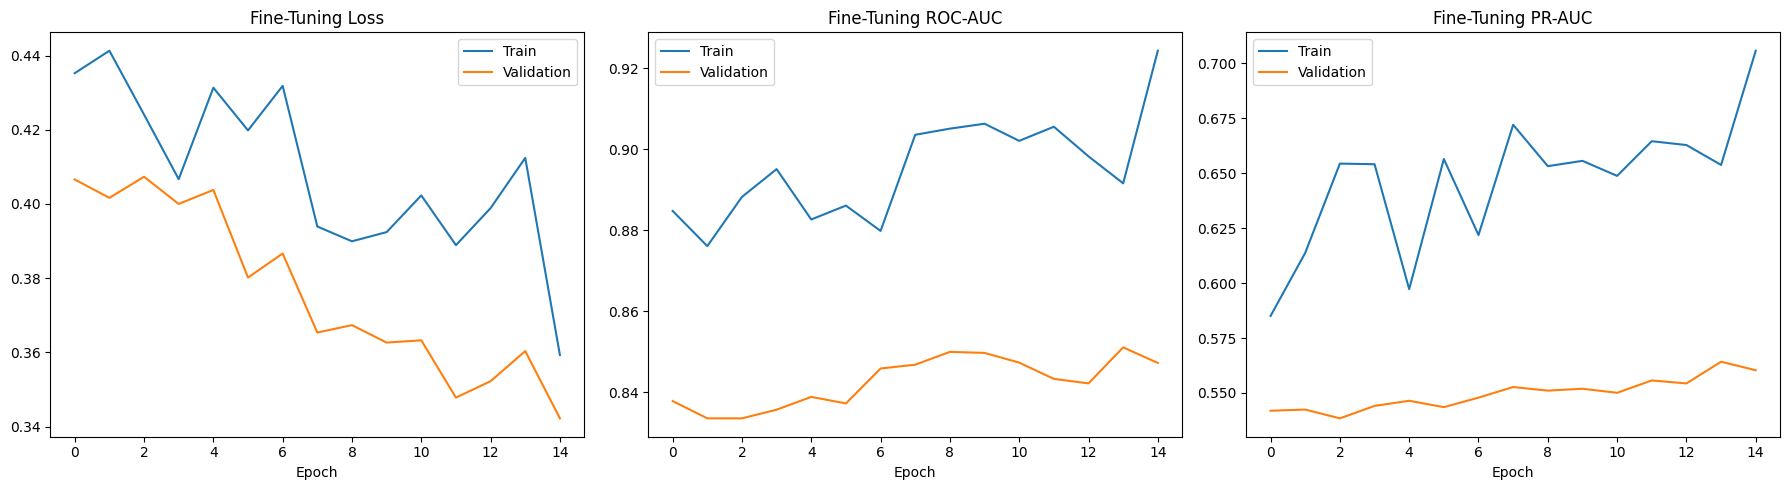

In [34]:
fine_tune_history_df = pd.DataFrame(
    fine_tune_history.history
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

axes[0].plot(
    fine_tune_history_df["loss"],
    label="Train"
)

axes[0].plot(
    fine_tune_history_df["val_loss"],
    label="Validation"
)

axes[0].set_title(
    "Fine-Tuning Loss"
)

axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(
    fine_tune_history_df["auc"],
    label="Train"
)

axes[1].plot(
    fine_tune_history_df["val_auc"],
    label="Validation"
)

axes[1].set_title(
    "Fine-Tuning ROC-AUC"
)

axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(
    fine_tune_history_df["pr_auc"],
    label="Train"
)

axes[2].plot(
    fine_tune_history_df["val_pr_auc"],
    label="Validation"
)

axes[2].set_title(
    "Fine-Tuning PR-AUC"
)

axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

## 22. Load Best Fine-Tuned Checkpoint

In [35]:
fine_tuned_best_model = (
    tf.keras.models.load_model(
        FINE_TUNE_BEST
    )
)

print(
    "Loaded fine-tuned checkpoint:"
)

print(FINE_TUNE_BEST)

Loaded fine-tuned checkpoint:
/content/drive/MyDrive/Dissertation/Models/EfficientNetB0_FineTune_Last30/best_model.keras


## 23. Evaluate Fine-Tuned Model on Validation Set

In [36]:
y_val_prob_fine_tuned = (
    fine_tuned_best_model.predict(
        validation_ds,
        verbose=1
    ).reshape(-1)
)

fine_tuned_val_roc_auc = (
    roc_auc_score(
        y_val,
        y_val_prob_fine_tuned
    )
)

fine_tuned_val_pr_auc = (
    average_precision_score(
        y_val,
        y_val_prob_fine_tuned
    )
)

print(
    "Fine-tuned validation ROC-AUC:",
    fine_tuned_val_roc_auc
)

print(
    "Fine-tuned validation PR-AUC:",
    fine_tuned_val_pr_auc
)

print(
    "Prediction minimum:",
    y_val_prob_fine_tuned.min()
)

print(
    "Prediction maximum:",
    y_val_prob_fine_tuned.max()
)

print(
    "Prediction mean:",
    y_val_prob_fine_tuned.mean()
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 591ms/step
Fine-tuned validation ROC-AUC: 0.8506493506493507
Fine-tuned validation PR-AUC: 0.5702772613104256
Prediction minimum: 0.05094638
Prediction maximum: 0.99542964
Prediction mean: 0.2782285


## 24. Select Fine-Tuned Validation Thresholds

In [37]:
precision_fine_tuned, recall_fine_tuned, thresholds_fine_tuned = (
    precision_recall_curve(
        y_val,
        y_val_prob_fine_tuned
    )
)

f1_fine_tuned = (
    2
    * precision_fine_tuned
    * recall_fine_tuned
    / (
        precision_fine_tuned
        + recall_fine_tuned
        + 1e-8
    )
)

fine_tuned_best_index = np.argmax(
    f1_fine_tuned[:-1]
)

fine_tuned_f1_threshold = (
    thresholds_fine_tuned[
        fine_tuned_best_index
    ]
)

print(
    "Fine-tuned F1 threshold:",
    fine_tuned_f1_threshold
)

print(
    "Precision:",
    precision_fine_tuned[
        fine_tuned_best_index
    ]
)

print(
    "Recall:",
    recall_fine_tuned[
        fine_tuned_best_index
    ]
)

print(
    "F1:",
    f1_fine_tuned[
        fine_tuned_best_index
    ]
)

Fine-tuned F1 threshold: 0.46439537
Precision: 0.6071428571428571
Recall: 0.6071428571428571
F1: 0.6071428521428572


In [38]:
fine_tuned_valid_indices = np.where(
    recall_fine_tuned[:-1]
    >= TARGET_RECALL
)[0]

if len(fine_tuned_valid_indices) > 0:

    fine_tuned_high_recall_index = (
        fine_tuned_valid_indices[
            np.argmax(
                precision_fine_tuned[
                    fine_tuned_valid_indices
                ]
            )
        ]
    )

    fine_tuned_high_recall_threshold = (
        thresholds_fine_tuned[
            fine_tuned_high_recall_index
        ]
    )

    print(
        "Fine-tuned high-recall threshold:",
        fine_tuned_high_recall_threshold
    )

    print(
        "Precision:",
        precision_fine_tuned[
            fine_tuned_high_recall_index
        ]
    )

    print(
        "Recall:",
        recall_fine_tuned[
            fine_tuned_high_recall_index
        ]
    )

else:
    fine_tuned_high_recall_threshold = None

    print(
        "No fine-tuned threshold achieved",
        TARGET_RECALL,
        "recall."
    )

Fine-tuned high-recall threshold: 0.32752764
Precision: 0.3559322033898305
Recall: 0.75


## 25. Compare Baseline and Fine-Tuned Validation Performance

In [39]:
baseline_val_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_baseline
)

baseline_val_pr_auc = (
    average_precision_score(
        y_val,
        y_val_prob_baseline
    )
)

validation_comparison = pd.DataFrame([
    {
        "Model": (
            "Frozen EfficientNetB0"
        ),
        "Validation_ROC_AUC": (
            baseline_val_roc_auc
        ),
        "Validation_PR_AUC": (
            baseline_val_pr_auc
        ),
        "F1_Threshold": (
            baseline_f1_threshold
        )
    },
    {
        "Model": (
            "Fine-Tuned Last 30 Layers"
        ),
        "Validation_ROC_AUC": (
            fine_tuned_val_roc_auc
        ),
        "Validation_PR_AUC": (
            fine_tuned_val_pr_auc
        ),
        "F1_Threshold": (
            fine_tuned_f1_threshold
        )
    }
])

display(validation_comparison)

,Model,Validation_ROC_AUC,Validation_PR_AUC,F1_Threshold
0,Frozen EfficientNetB0,0.832707,0.545594,0.432004
1,Fine-Tuned Last 30 Layers,0.850649,0.570277,0.464395


In [40]:
if (
    fine_tuned_val_pr_auc
    > baseline_val_pr_auc
):

    selected_model_name = (
        "Fine-Tuned EfficientNetB0"
    )

    selected_model = (
        fine_tuned_best_model
    )

    selected_f1_threshold = (
        fine_tuned_f1_threshold
    )

    selected_high_recall_threshold = (
        fine_tuned_high_recall_threshold
    )

else:

    selected_model_name = (
        "Frozen EfficientNetB0"
    )

    selected_model = baseline_model

    selected_f1_threshold = (
        baseline_f1_threshold
    )

    selected_high_recall_threshold = (
        baseline_high_recall_threshold
    )

print(
    "Selected final model:",
    selected_model_name
)

Selected final model: Fine-Tuned EfficientNetB0


### Final model selection

The fine-tuned EfficientNetB0 model was selected using validation PR-AUC. It achieved a validation PR-AUC of 0.5534 compared with 0.5313 for the frozen-backbone baseline. The untouched test set was not used during model selection.


## 26. Final Evaluation on the Untouched Test Set

In [41]:
y_test = np.concatenate([
    labels.numpy().reshape(-1)
    for _, labels in test_ds
])

y_test_prob_selected = (
    selected_model.predict(
        test_ds,
        verbose=1
    ).reshape(-1)
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob_selected
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_prob_selected
)

print(
    "Selected model:",
    selected_model_name
)

print(
    "Test ROC-AUC:",
    test_roc_auc
)

print(
    "Test PR-AUC:",
    test_pr_auc
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
Selected model: Fine-Tuned EfficientNetB0
Test ROC-AUC: 0.8302521008403362
Test PR-AUC: 0.6337360925330153


Threshold evaluation

In [42]:
thresholds_to_evaluate = {
    "Default_0.50": 0.50,
    "Validation_F1": (
        selected_f1_threshold
    )
}

if (
    selected_high_recall_threshold
    is not None
):
    thresholds_to_evaluate[
        "Validation_HighRecall"
    ] = selected_high_recall_threshold

test_results = []

for threshold_name, threshold in (
    thresholds_to_evaluate.items()
):

    y_test_pred = (
        y_test_prob_selected
        >= threshold
    ).astype(np.int32)

    cm = confusion_matrix(
        y_test,
        y_test_pred
    )

    tn, fp, fn, tp = cm.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    test_results.append({
        "Model": selected_model_name,
        "ThresholdName": threshold_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred
        ),
        "Precision": precision_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),
        "Sensitivity": recall_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),
        "Specificity": specificity,
        "F1": f1_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    print(
        f"\n--- {threshold_name} ---"
    )

    print(cm)

    print(
        classification_report(
            y_test,
            y_test_pred,
            target_names=[
                "Benign",
                "Malignant"
            ],
            digits=4,
            zero_division=0
        )
    )

test_results_df = pd.DataFrame(
    test_results
)

display(test_results_df)


--- Default_0.50 ---
[[207  14]
 [ 15  20]]
              precision    recall  f1-score   support

      Benign     0.9324    0.9367    0.9345       221
   Malignant     0.5882    0.5714    0.5797        35

    accuracy                         0.8867       256
   macro avg     0.7603    0.7540    0.7571       256
weighted avg     0.8854    0.8867    0.8860       256


--- Validation_F1 ---
[[205  16]
 [ 15  20]]
              precision    recall  f1-score   support

      Benign     0.9318    0.9276    0.9297       221
   Malignant     0.5556    0.5714    0.5634        35

    accuracy                         0.8789       256
   macro avg     0.7437    0.7495    0.7465       256
weighted avg     0.8804    0.8789    0.8796       256


--- Validation_HighRecall ---
[[181  40]
 [  9  26]]
              precision    recall  f1-score   support

      Benign     0.9526    0.8190    0.8808       221
   Malignant     0.3939    0.7429    0.5149        35

    accuracy                         

,Model,ThresholdName,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,TN,FP,FN,TP
0,Fine-Tuned EfficientNetB0,Default_0.50,0.500000,0.886719,0.588235,0.571429,0.936652,0.579710,207,14,15,20
1,Fine-Tuned EfficientNetB0,Validation_F1,0.464395,0.878906,0.555556,0.571429,0.927602,0.563380,205,16,15,20
2,Fine-Tuned EfficientNetB0,Validation_HighRecall,0.327528,0.808594,0.393939,0.742857,0.819005,0.514851,181,40,9,26


### Test-set usage

The test set was evaluated only after model architecture, fine-tuning strategy and decision thresholds had been selected using the training and validation sets. No further model or threshold optimisation will be performed using test-set results.

## 27. Plot Final ROC and Precision–Recall Curves

In [43]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)

fpr, tpr, _ = roc_curve(
    y_test,
    y_test_prob_selected
)

test_roc_curve_auc = auc(
    fpr,
    tpr
)

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        y_test_prob_selected
    )
)

test_pr_curve_auc = average_precision_score(
    y_test,
    y_test_prob_selected
)

###ROC curve

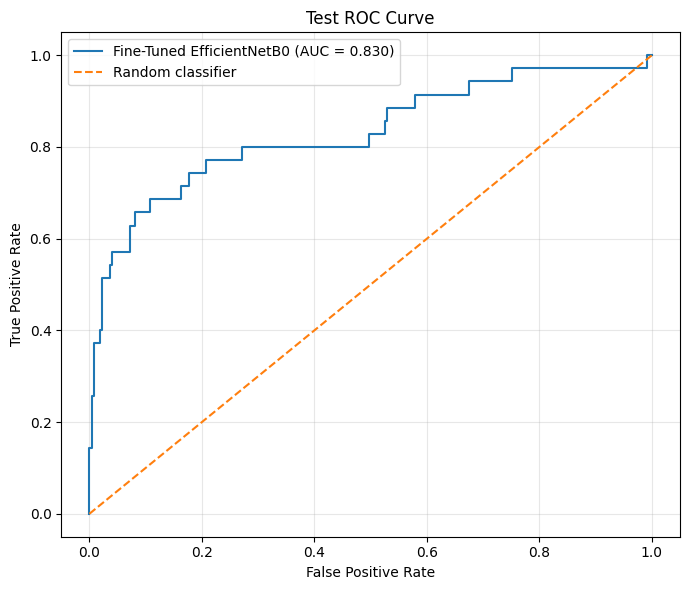

In [44]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=(
        f"Fine-Tuned EfficientNetB0 "
        f"(AUC = {test_roc_curve_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###Precision-recall curve

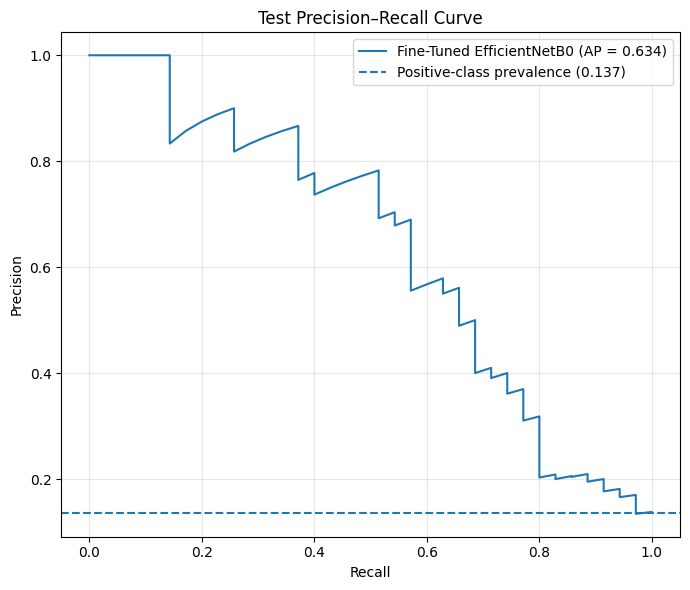

In [45]:
test_positive_prevalence = np.mean(
    y_test
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=(
        f"Fine-Tuned EfficientNetB0 "
        f"(AP = {test_pr_curve_auc:.3f})"
    )
)

plt.axhline(
    y=test_positive_prevalence,
    linestyle="--",
    label=(
        "Positive-class prevalence "
        f"({test_positive_prevalence:.3f})"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 28. Plot Final Confusion Matrices

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix_for_threshold(
    y_true,
    probabilities,
    threshold,
    title
):
    predictions = (
        probabilities >= threshold
    ).astype(np.int32)

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        predictions,
        display_labels=[
            "Benign",
            "Malignant"
        ],
        values_format="d"
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

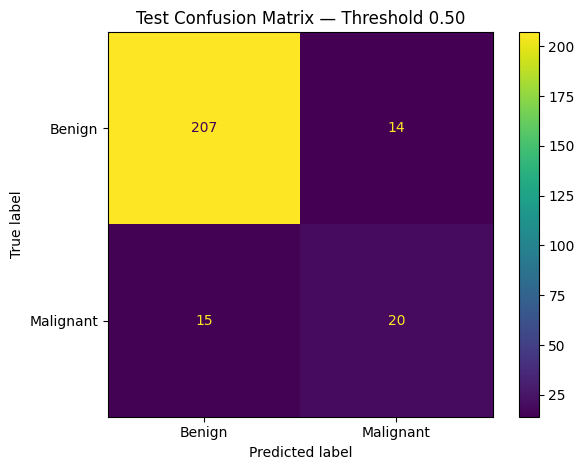

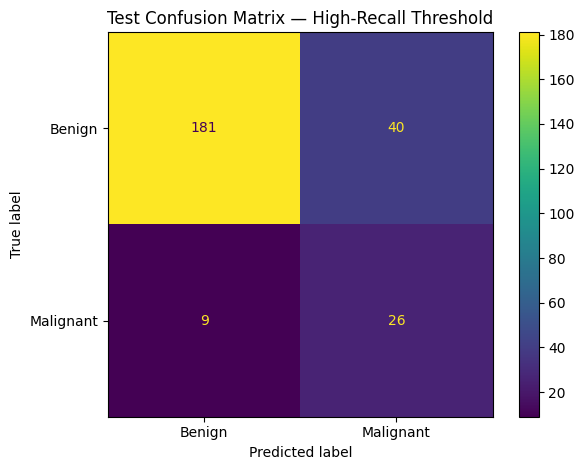

In [47]:
plot_confusion_matrix_for_threshold(
    y_test,
    y_test_prob_selected,
    0.50,
    "Test Confusion Matrix — Threshold 0.50"
)

plot_confusion_matrix_for_threshold(
    y_test,
    y_test_prob_selected,
    selected_high_recall_threshold,
    (
        "Test Confusion Matrix — "
        "High-Recall Threshold"
    )
)

## 29. Save Final Experiment Summary

In [48]:
FINAL_RESULTS_PATH = (
    FINE_TUNE_DIR
    / "final_test_results.csv"
)

test_results_df.to_csv(
    FINAL_RESULTS_PATH,
    index=False
)

model_summary_results = pd.DataFrame([
    {
        "SelectedModel": selected_model_name,
        "ValidationROC_AUC": fine_tuned_val_roc_auc,
        "ValidationPR_AUC": fine_tuned_val_pr_auc,
        "TestROC_AUC": test_roc_auc,
        "TestPR_AUC": test_pr_auc,
        "DefaultThreshold": 0.50,
        "ValidationF1Threshold": selected_f1_threshold,
        "HighRecallThreshold": (
            selected_high_recall_threshold
        )
    }
])

SUMMARY_PATH = (
    FINE_TUNE_DIR
    / "model_summary.csv"
)

model_summary_results.to_csv(
    SUMMARY_PATH,
    index=False
)

print("Saved:", FINAL_RESULTS_PATH)
print("Saved:", SUMMARY_PATH)

Saved: /content/drive/MyDrive/Dissertation/Models/EfficientNetB0_FineTune_Last30/final_test_results.csv
Saved: /content/drive/MyDrive/Dissertation/Models/EfficientNetB0_FineTune_Last30/model_summary.csv
